# Trabajo Semanal N°7 : 'Filtrado Digital de ECG'
### Alumno: Magdalena Guida

### APS - 1er cuatrimestre 2026


Este trabajo tiene como objetivo el diseño y comparacion de filtros **FIR** e **IIR** aplicados sobre un electrocardiograma (ECG), una señal biomedica que muestra la actividad electrica del corazon, que presenta los siguientes fuentes de contaminacion: 
- Ruido de *alta frecuencia* por movimiento de electrodos.
- Ruido muscular (EMG) de *alta frecuencia*.
- Movimiento de la linea de base del ECG de *baja frecuencia*.


Primero, se realizo el diseño de la plantilla. Se definieron los valores de 'stop' y 'pass' y la atenuacion especifica para cada rango. Primer banda de stop entre las frecuencias $[0; 0.1]Hz$ con una atenuacion de $-20dB$ para asegurarse que mitigue la linea de base producida por la respiracion. Luego una banda de transcicion definida por $ws_1  = 0.1Hz $ y $wp_1 =1Hz$, a continuacion la banda de paso entre $wp_1$ y $wp_2 = 35Hz$ con un rizado maximo premitido definido como $gpass = 1dB$ y por ultimo la ultima banda de *STOP* desde $ws_2 = 45Hz$ hasta la frecuencia de Nyquist: $fs/2 = 500Hz$ con una atenuacion minima de $gstop =40dB$. Asi se preserva la onda QRS que se concentra entre los $[5;35]Hz$ y se mitiga el EMG que comienza a partir de los $45Hz$. A continuacion se muestra el codigo que define la plantilla implementada. Ademas se agregan las primeras lineas de codigo para la lectura del ECG.

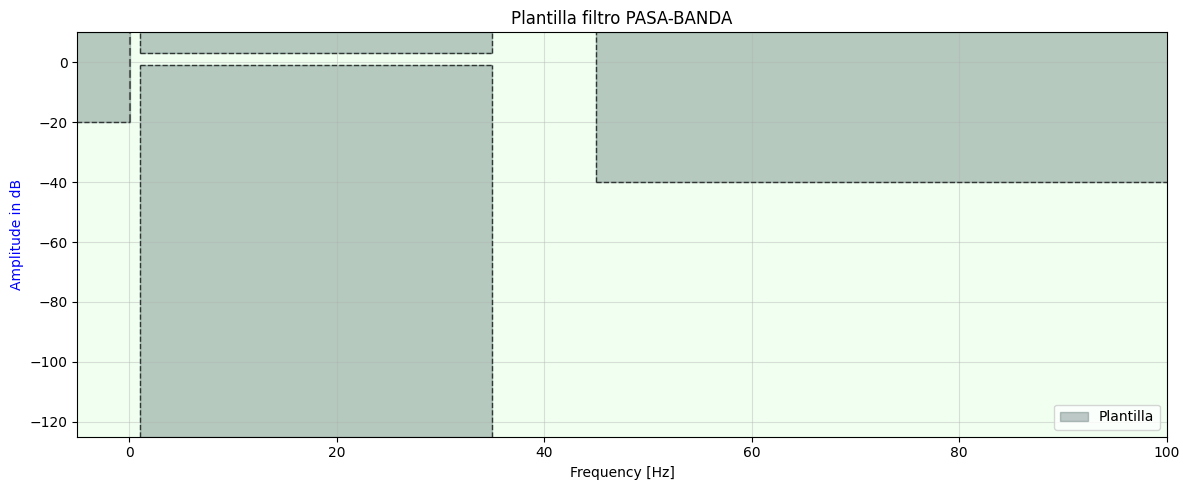

In [1]:
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio

#%% LECTURA ECG 
mat_struct = sio.loadmat('./pdstestbench/ECG_TP4.mat')
ecg = mat_struct['ecg_lead'].squeeze()   # <-- convierte (N,1) en (N,)
ecg = ecg - np.mean(ecg)
N = len(ecg)
fs = 1000

#%%    GRAFICOS
# =============================================================================
# BLOQUE DE PLOT CON PLANTILLA DE DISEÑO (SOMBRADA)
# =============================================================================

fig, ax1 = plt.subplots(figsize=(12, 5), tight_layout=True)
ax1.set_title("Plantilla filtro PASA-BANDA")

ax1.fill_between([-5,100], -125, 10, color='honeydew')
piso_grafico = -125
techo_grafico = 10
gpass = 1
gstop = 40

# --- Banda de parada 1 (0 a 0.1) ---
ax1.fill_between([-10, 0.1], -20, techo_grafico, color='darkslategray', alpha=0.3, label='Plantilla')
ax1.plot([-10, 0.1], [-20, -20],  color='k',linestyle='--', linewidth=1, alpha=0.7) 

# --- Banda de paso (1 a 35) ---
#Zona inferior
ax1.fill_between([1, 35], piso_grafico, -gpass, color='darkslategray', alpha=0.3)
ax1.plot([1, 35], [-gpass, -gpass],  color='k',linestyle='--', linewidth=1, alpha=0.7)
# Zona superior 
ax1.fill_between([1, 35], 3, techo_grafico, color='darkslategray', alpha=0.3)
ax1.plot([1, 35], [3, 3],  color='k',linestyle='--', linewidth=1, alpha=0.7)

# --- Banda de parada 2 (45 a Nyquist) ---
ax1.fill_between([45, fs/2], -gstop, techo_grafico, color='darkslategray', alpha=0.3)
ax1.plot([45, fs/2], [-gstop, -gstop],  color='k',linestyle='--', linewidth=1, alpha=0.7)

##Líneas verticales que delimitan los saltos de las bandas
ax1.vlines(0.1,-20, techo_grafico, color='k', linestyle='--', alpha=0.5)
ax1.vlines( 1, piso_grafico, -1,  color='k',linestyle='--', linewidth=1, alpha=0.7)
ax1.vlines(35, piso_grafico, -1, color='k',linestyle='--', linewidth=1, alpha=0.7)
ax1.vlines( 1, 3, techo_grafico,  color='k',linestyle='--', linewidth=1, alpha=0.7)
ax1.vlines(35, 3, techo_grafico, color='k',linestyle='--', linewidth=1, alpha=0.7)
ax1.vlines(45, -gstop, techo_grafico, color='k',linestyle='--', linewidth=1, alpha=0.7)

ax1.set_ylabel('Amplitude in dB', color='b')
ax1.set_xlabel('Frequency [Hz]')
ax1.grid(True, which='both', linestyle='-', alpha=0.4)
ax1.legend(loc='lower right')
ax1.set_ylim([piso_grafico, techo_grafico]) 
ax1.set_xlim(-5, 100)
plt.show()

En segunda instancia, se diseñaron 4 filtros, 2 FIR y 2 IIR. Como primer metodo de filtro FIR se utilizo el Metodo de Ventanas, utilizando la funcion *signal.firwin* con la eleccion de ventana: *Hamming*. Las frecuencias de corte se modificaron un poco para lograr tener un margen de error, y el orden se definio experimentalmente, siempre con numeros impares, ya que es un requerimiento de la funcion para crear un filtro pasa-banda.  Para la aplicacion del filtro, se uso la funcion *filtfilt* para que la respuesta de fae sea cero, y asi evitar distorcion temporal del ECG. Tambien, se aplico Cuadrados Minimos como el segundo metodo para el calculo de los filtros FIR, que minimiza el error cuadratico entre la respuesta deseada y la obtenida. Se le define la variable $wights$, para indicar en que bandas debe desempeñarse con mayor enfasis. Al primer tramo se le define $10$ para que logre transitar $20dB$ en $0.9Hz$, lo cual es bastate exigente. Se proyecta como la respuesta en frecuencia cumple con el filtro, pero sin embargo, cuando se le aplique al ECG, los resultados no son favorables.

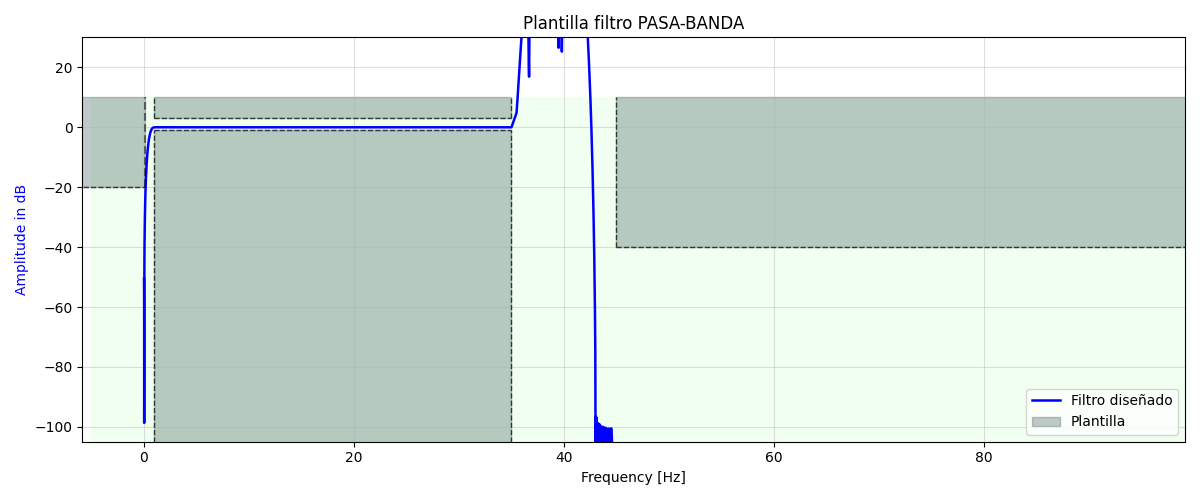

In [2]:
#%% FILTROS FIR
############################################
# DISEÑO FILTRO POR VENTANAS 
############################################

nyq_frec = fs / 2
gpass = 1 #[dB]
gstop = 40 #[dB]
ws1 = .5
wp1 = .55
wp2 = 35.5
ws2 = 40

orden = 2501
b_coeffs_vent = signal.firwin(orden, 
                              [wp1, wp2], 
                              window='hamming',
                              pass_zero=False, 
                              fs=fs)
taps = b_coeffs_vent.shape[0]

############################################
# DISEÑO FILTRO POR CUADRADOS MINIMOS
############################################

nyq_frec = fs / 2
gpass = 1 #[dB]
gstop = 40 #[dB]
ws1 = .05
wp1 = .95
wp2 = 35
ws2 = 43

bandas = np.array([0, ws1, wp1, wp2, ws2, nyq_frec])
gains= np.array([0, 0, 1, 1, 0, 0])
weight = np.array([10,2,1])
orden = 3001

b_coeffs_cmin = signal.firls(orden, 
                        bands = bandas, 
                        desired = gains, 
                        weight = weight, 
                        fs=fs)
taps = b_coeffs_cmin.shape[0]

from IPython.display import Image 
Image(r"..\TS 7\filt cmin.png")

Los filtros IIR fueron ambos diseñados con la funcion *signal.iirdesign* que obtiene el orden minimo requerido para cumplir con las especificaciones de manera automatica y devuelve la salida en formato de SOS: secciones de segundo orden. El primero definido con un *ftype = 'butter'* es un filtro Butterworth de maxima planicidad en la banda de paso, a costa de una transicion mas suave que requiere un orden mayor. Para el ultimo filtro, se aplico *ftype = 'cheby2*, un Chebyshev de tipo 2. Se le tuvieron que aplicar $45dB$ como *gstop*, para darle un margen y que logre cumplir los $40dB$ requeridos por la plantilla.

In [3]:
#%% FILTROS IIR 
###########################################
##DISEÑO FILTRO IIR MAXIMA PLANICIDAD
###########################################
fs = 1000 
wp = [0.8, 37]
ws = [0.1, 40]
gpass = 1
gstop = 40

b_coeffs_butter = signal.iirdesign(wp, 
                                   ws, 
                                   gpass, 
                                   gstop, 
                                   ftype= 'butter',  
                                   output= 'sos', 
                                   fs = fs )

############################################
# DISEÑO FILTRO IIR CHEBYSHEV2
############################################
fs = 1000 
wp = [0.8, 37]
ws = [0.1, 40]
gpass = 1
gstop = 40

b_coeffs_cheby2 = signal.iirdesign(wp, 
                                   ws, 
                                   gpass, 
                                   45, 
                                   ftype= 'cheby2',  
                                   output= 'sos', 
                                   fs = fs )

Todos los filtros fueron verificados contra la plantilla diseñada, usando las funciones *signal.freqz* para los FIR y *signal.sosfreqz* para los IIR. Ademas se diseño un vector $ww$ de frecuencias no uniforme para darle mayor densidad a las zonas de interes. Todos los filtros cumplieron con la plantilla.  Por ultimo se analizaron los primeros 5 segundos del registro del ECG para la comparacion visual del desempeño de los filtros. Se agrega para facilitar la comparacion la señal sin filtro.  Ademas, se recortaron zonas de interes para poder analizar las ondas caracteristicas de la señal biologica con mas detalle.

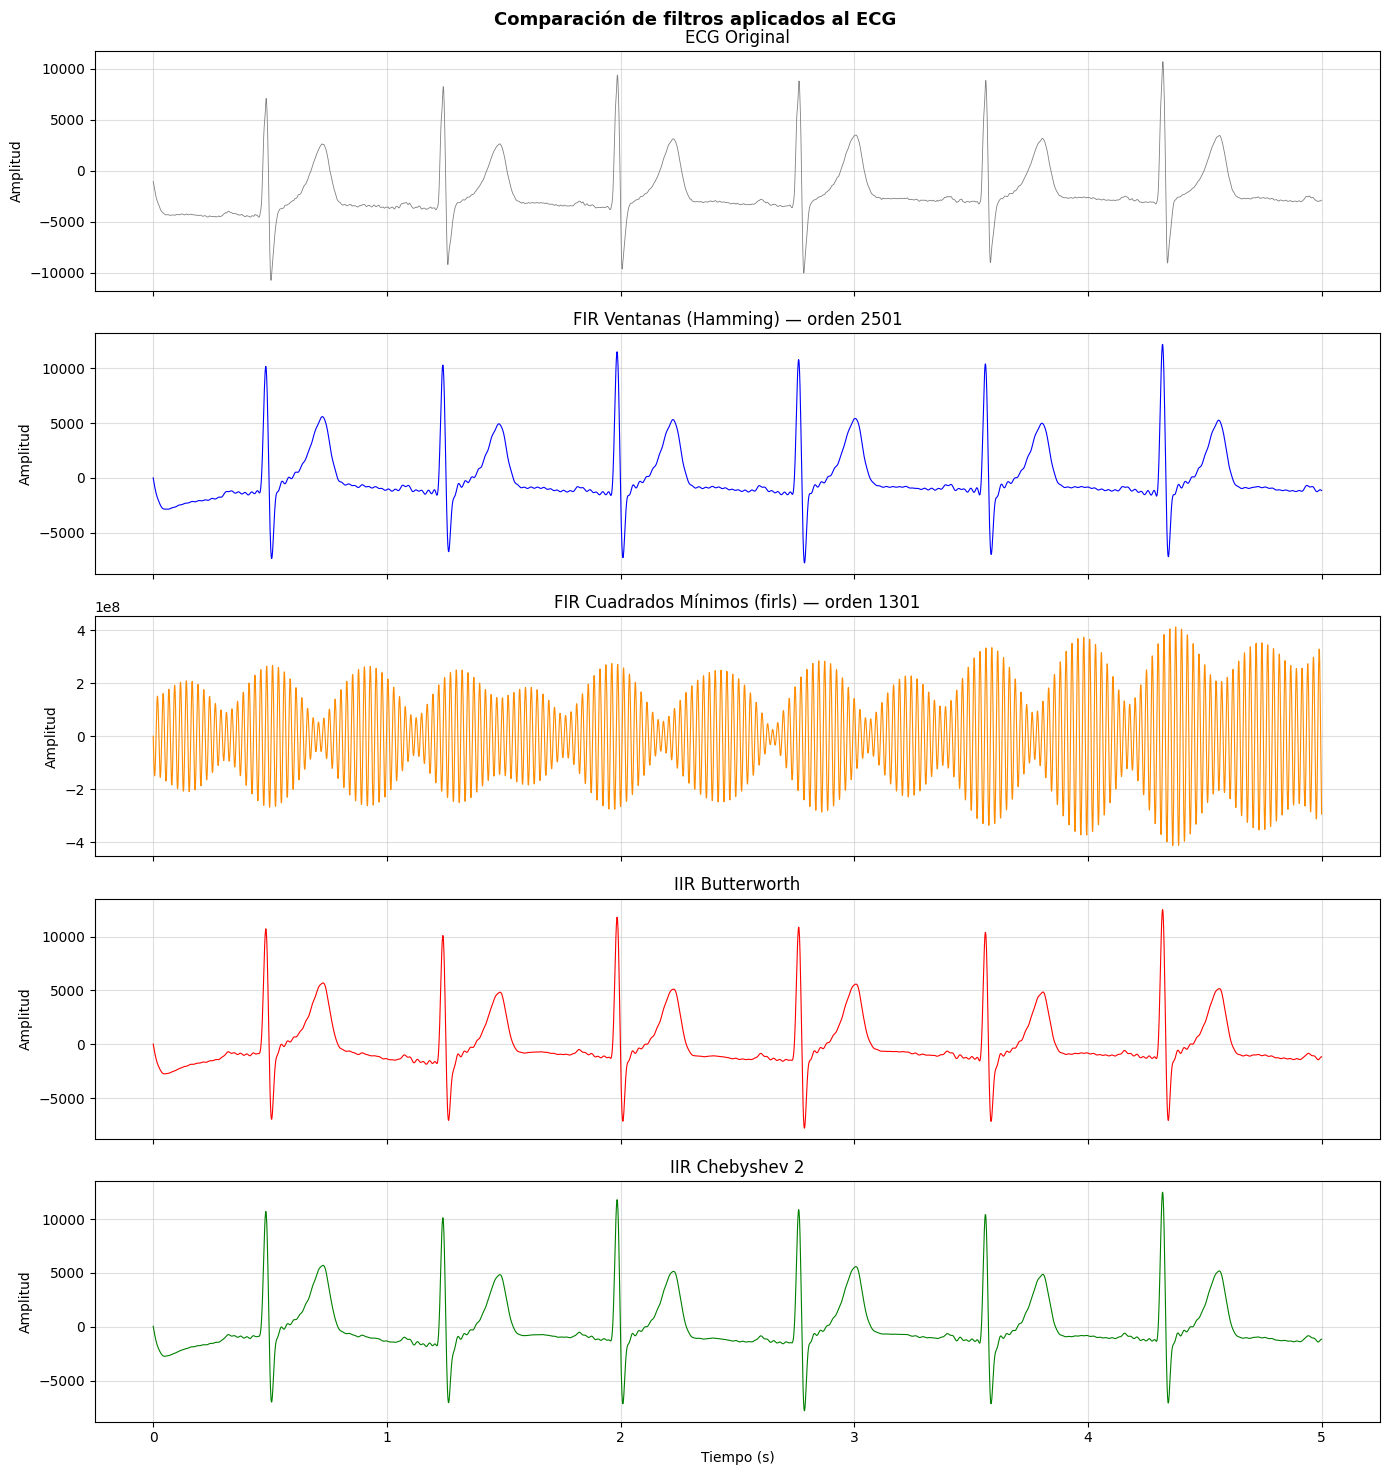

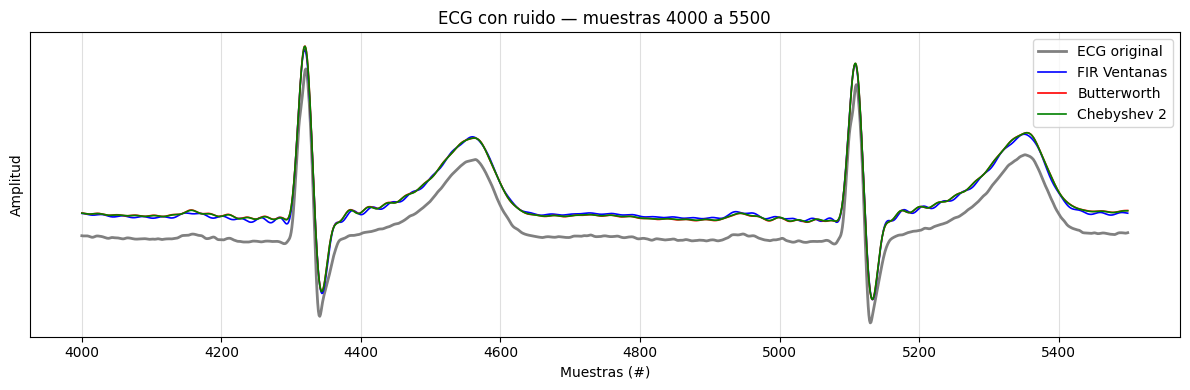

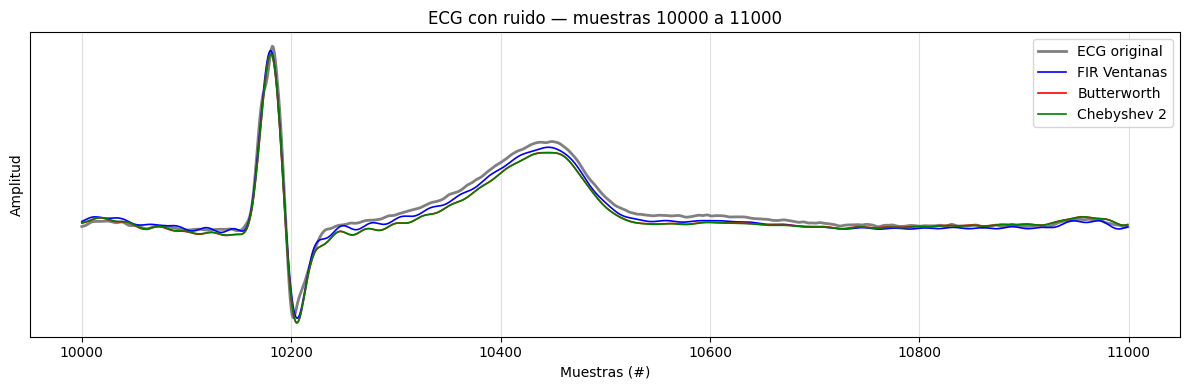

In [5]:
#%% APLICACION DE LOS FILTROS

# FIR 
ecg_fir_vent = signal.filtfilt(b_coeffs_vent, [1], ecg)
ecg_fir_cmin = signal.filtfilt(b_coeffs_cmin, [1], ecg)
ecg_iir_cheby2 = signal.sosfiltfilt(b_coeffs_cheby2, ecg)
ecg_iir_butter = signal.sosfiltfilt(b_coeffs_butter, ecg)

# Mostrar solo 5 segundos
t = np.arange(N) / fs
t_ini = 0
t_fin = 5
mask = (t >= t_ini) & (t <= t_fin)
fig, axes = plt.subplots(5, 1, figsize=(14, 15), sharex=True, tight_layout=True)

# ── ECG original ──────────────────────────────────────
axes[0].plot(t[mask], ecg[mask],
             color='gray', linewidth=0.6)
axes[0].set_title('ECG Original')

# ── FIR Ventanas ──────────────────────────────────────
axes[1].plot(t[mask], ecg_fir_vent[mask],
             color='blue', linewidth=0.8)
axes[1].set_title('FIR Ventanas (Hamming) — orden 2501')

# ── FIR Cuadrados Mínimos ─────────────────────────────
axes[2].plot(t[mask], ecg_fir_cmin[mask],
             color='darkorange', linewidth=0.8)
axes[2].set_title('FIR Cuadrados Mínimos (firls) — orden 1301')

# ── IIR Butterworth ───────────────────────────────────
axes[3].plot(t[mask], ecg_iir_butter[mask],
             color='red', linewidth=0.8)
axes[3].set_title('IIR Butterworth')

# ── IIR Chebyshev 2 ───────────────────────────────────
axes[4].plot(t[mask], ecg_iir_cheby2[mask],
             color='green', linewidth=0.8)
axes[4].set_title('IIR Chebyshev 2')
axes[4].set_xlabel('Tiempo (s)')

for ax in axes:
    ax.set_ylabel('Amplitud')
    ax.grid(True, alpha=0.4)

plt.suptitle('Comparación de filtros aplicados al ECG',
             fontsize=13, fontweight='bold')
plt.show()

cant_muestras = N   # len(ecg)
ecg_one_lead  = ecg
# Demora 
demora = 0 

###################################
# Regiones de interes
###################################
regs_interes = (
    [4000,  5500],
    [10000, 11000],
)

for ii in regs_interes:
    zoom_region = np.arange(np.max([0, ii[0]]),
                            np.min([cant_muestras, ii[1]]),
                            dtype='uint')

    plt.figure(figsize=(12, 4))
    plt.plot(zoom_region, ecg_one_lead[zoom_region],
             label='ECG original', linewidth=2, color='gray')
    plt.plot(zoom_region, ecg_fir_vent[zoom_region + demora],
             label='FIR Ventanas', linewidth=1.2, color='blue')
    plt.plot(zoom_region, ecg_iir_butter[zoom_region + demora],
             label='Butterworth', linewidth=1.2, color='red')
    plt.plot(zoom_region, ecg_iir_cheby2[zoom_region + demora],
             label='Chebyshev 2', linewidth=1.2, color='green')

    plt.title(f'ECG con ruido — muestras {ii[0]} a {ii[1]}')
    plt.ylabel('Amplitud')
    plt.xlabel('Muestras (#)')
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.gca().set_yticks(())  
    plt.tight_layout()
    plt.show()

Los resultados muestran: para FIR de Ventanas se elimina correctamente el DC y el ruido de altas frecuencias. La onda QRS presenta una buena morfologia dada por el orden alto. El filtro de cuadrados minimos, cuando se llevo a la practica, no se logro su correcta aplicacion, muestra amplitudes mayores a los $4*10^8$, que indica muchisima inestabilidad numerica que podria ser causada por el orden usado=1301, aunque, se trato con otros menores pero no se lograron resultados favorables. Los filtros IIR presentaron muy buenos resultados, con señales limpias y morfologias de las ondas QRS y T nitidas y preservadas. La banda depaso plana del filtro tipo Chebyshev se diferencia de la Butterworth favoreciendo todavia mas la fidelidad morfologica. 

La principal diferencia entre los filtros IIR y FIR recae sobre el orden necesario para cumplir los mismos requisitos. Mientras los IIR utilizan CheBy: orden  $\approx 12$ y Butter: orden $\approx 18$ y el filtro FIR por ventanas orden: $2501$. Esto implica un mayor costo computacional y retardo de grupo. Sin embargo, tienen fase lineal garantizada, mientras que los IIR no. Igualmente, se logro cancelar con la funcion *filtfilt*, que aplica el filtro en dos pasadas. 


A lo largo de este trabajo se construyeron cuatro filtro digitales pasa-banda para limpiar una señal de ECG. Con elobjetivo de identificar sus ondas caracteristicas lo mas nitido posible. Se diseño una plantilla estableciendo las frecuencias de corte, frecuencias de paso y los niveles de atenuacion para cumplir con las necesidades requeridas para el filtrado de una señal biologica,  apoyandose en el BW previamente calculado. 

Los filtros IIR resultaron los mas eficientes, con el menor orden y costo computacional, presentando resultados visuales superiores. El filtro FIR por ventanas, cumplio correctamente con la plantilla y produjo una señal de buena calidad, requireiendo un orden 100 veces mayor a los filtros IIR, pero con fase lineal garantizada. El filtro FIR por cuadrados minimos cumplio con la plantilla pero no se logro su aplicacione a la señal.  